Variables categóricas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
plt.rcParams.update({'figure.dpi': 110})


In [4]:
leads = pd.read_csv('Analisis_GAC_Full7agosto_2026_LeadsReales.csv')
leads = leads.iloc[1:].reset_index(drop=True)
leads.columns = ['Año','Mes','Total','Ilocalizable','No_Contesta','D_Incorrectos',
                  'Duplicados','Efectivos','Abiertos','Ventas','Conversion','Efectividad','x1','x2']
leads = leads.drop(columns=['x1','x2'])
leads = leads.dropna(subset=['Mes'])
leads['Mes'] = leads['Mes'].astype(str).str.strip()          # <- quita espacios ("Enero " -> "Enero")
leads = leads[leads['Mes'] != 'Mes']
leads['Año'] = leads['Año'].ffill()
leads = leads.dropna(subset=['Total'])

for c in ['Total','Ilocalizable','No_Contesta','D_Incorrectos','Duplicados','Efectivos','Abiertos','Ventas']:
    leads[c] = pd.to_numeric(leads[c].astype(str).str.replace(',', ''), errors='coerce')
leads['Conversion'] = pd.to_numeric(leads['Conversion'].astype(str).str.replace('%',''), errors='coerce')
leads['Efectividad'] = pd.to_numeric(leads['Efectividad'].astype(str).str.replace('%',''), errors='coerce')
leads = leads[leads['Mes'] != 'Prome.']
leads['Año'] = leads['Año'].astype(int)
leads = leads.reset_index(drop=True)

print("Nulos antes de limpiar:\n", leads.isnull().sum())
leads = leads.dropna()
print("Nulos después de limpiar:\n", leads.isnull().sum())
leads.to_csv('leads_reales_clean.csv', index=False)

# Orden cronológico real de los meses y periodo Mes-Año para no repetir etiquetas
orden_meses = ['Enero','Febrero','Marzo','Abril','Mayo','Junio','Julio','Agosto',
               'Septiembre','Octubre','Noviembre','Diciembre']
leads['Mes'] = pd.Categorical(leads['Mes'], categories=orden_meses, ordered=True)
leads['Periodo'] = leads['Mes'].astype(str).str[:3] + '-' + leads['Año'].astype(str).str[-2:]

Nulos antes de limpiar:
 Año              0
Mes              0
Total            0
Ilocalizable     0
No_Contesta      0
D_Incorrectos    0
Duplicados       0
Efectivos        0
Abiertos         0
Ventas           0
Conversion       0
Efectividad      0
dtype: int64
Nulos después de limpiar:
 Año              0
Mes              0
Total            0
Ilocalizable     0
No_Contesta      0
D_Incorrectos    0
Duplicados       0
Efectivos        0
Abiertos         0
Ventas           0
Conversion       0
Efectividad      0
dtype: int64


In [4]:
# Función auxiliar: pone el número exacto arriba de cada barra
def etiquetar_barras(ax):
    for cont in ax.containers:
        ax.bar_label(cont, fontsize=9, padding=2)

Numericas

[Total] n=28, Max=1973, Min=178, R=1795, ni=6, i=299.17


NameError: name 'etiquetar_barras' is not defined

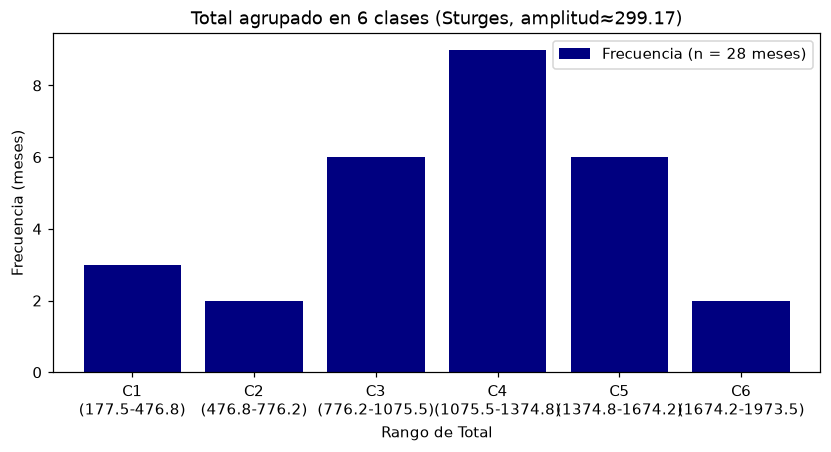

In [5]:
col = 'Total'; nombre = 'Total'
n = leads[col].count()
Max = leads[col].max(); Min = leads[col].min()
R = Max - Min
ni = int(round(1 + 3.32*np.log10(n)))
i = R/ni
print(f"[{nombre}] n={n}, Max={Max}, Min={Min}, R={R}, ni={ni}, i={round(i,2)}")

intervalos = np.linspace(Min-0.5, Max+0.5, ni+1)
categorias = [f"C{k+1}\n({round(intervalos[k],1)}-{round(intervalos[k+1],1)})" for k in range(ni)]
leads[f'{col}_clase'] = pd.cut(leads[col], bins=intervalos, labels=categorias)

Tabla_freq = leads[f'{col}_clase'].value_counts().sort_index().reset_index()
Tabla_freq.columns = ['Clase', 'count']
Filtro_index = Tabla_freq.set_index('Clase')
Filtro_index.columns = [f'Frecuencia (n = {n} meses)']

ax = Filtro_index.plot(kind='bar', width=0.8, color='navy', figsize=(9,4), legend=True, rot=0)
plt.title(f'{nombre} agrupado en {ni} clases (Sturges, amplitud≈{round(i,2)})')
plt.xlabel(f'Rango de {nombre}'); plt.ylabel('Frecuencia (meses)')
etiquetar_barras(ax)
plt.tight_layout(); plt.show()

[Ilocalizable] n=28, Max=514, Min=5, R=509, ni=6, i=84.83


NameError: name 'etiquetar_barras' is not defined

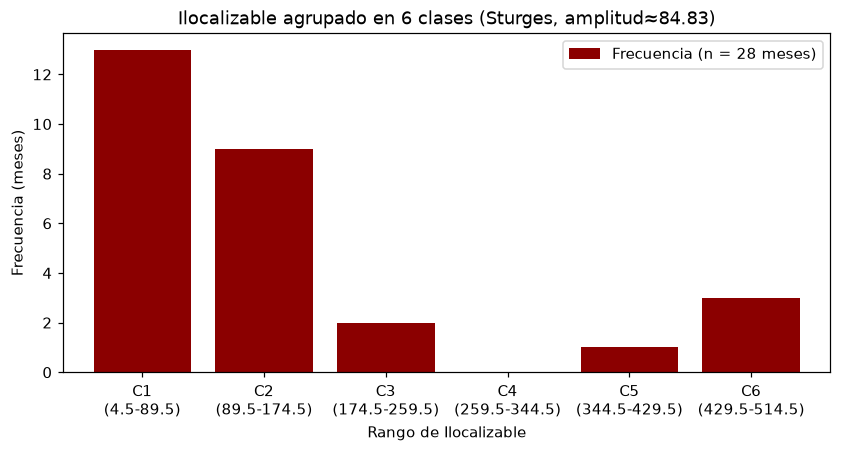

In [6]:
col = 'Ilocalizable'; nombre = 'Ilocalizable'
n = leads[col].count()
Max = leads[col].max(); Min = leads[col].min()
R = Max - Min
ni = int(round(1 + 3.32*np.log10(n)))
i = R/ni
print(f"[{nombre}] n={n}, Max={Max}, Min={Min}, R={R}, ni={ni}, i={round(i,2)}")

intervalos = np.linspace(Min-0.5, Max+0.5, ni+1)
categorias = [f"C{k+1}\n({round(intervalos[k],1)}-{round(intervalos[k+1],1)})" for k in range(ni)]
leads[f'{col}_clase'] = pd.cut(leads[col], bins=intervalos, labels=categorias)

Tabla_freq = leads[f'{col}_clase'].value_counts().sort_index().reset_index()
Tabla_freq.columns = ['Clase', 'count']
Filtro_index = Tabla_freq.set_index('Clase')
Filtro_index.columns = [f'Frecuencia (n = {n} meses)']

ax = Filtro_index.plot(kind='bar', width=0.8, color='darkred', figsize=(9,4), legend=True, rot=0)
plt.title(f'{nombre} agrupado en {ni} clases (Sturges, amplitud≈{round(i,2)})')
plt.xlabel(f'Rango de {nombre}'); plt.ylabel('Frecuencia (meses)')
etiquetar_barras(ax)
plt.tight_layout(); plt.show()

[No Contesta] n=28, Max=606, Min=13, R=593, ni=6, i=98.83


NameError: name 'etiquetar_barras' is not defined

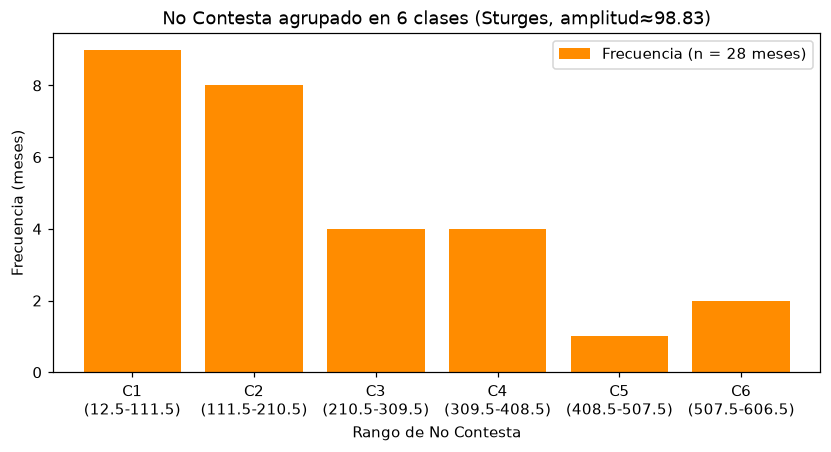

In [7]:
col = 'No_Contesta'; nombre = 'No Contesta'
n = leads[col].count()
Max = leads[col].max(); Min = leads[col].min()
R = Max - Min
ni = int(round(1 + 3.32*np.log10(n)))
i = R/ni
print(f"[{nombre}] n={n}, Max={Max}, Min={Min}, R={R}, ni={ni}, i={round(i,2)}")

intervalos = np.linspace(Min-0.5, Max+0.5, ni+1)
categorias = [f"C{k+1}\n({round(intervalos[k],1)}-{round(intervalos[k+1],1)})" for k in range(ni)]
leads[f'{col}_clase'] = pd.cut(leads[col], bins=intervalos, labels=categorias)

Tabla_freq = leads[f'{col}_clase'].value_counts().sort_index().reset_index()
Tabla_freq.columns = ['Clase', 'count']
Filtro_index = Tabla_freq.set_index('Clase')
Filtro_index.columns = [f'Frecuencia (n = {n} meses)']

ax = Filtro_index.plot(kind='bar', width=0.8, color='darkorange', figsize=(9,4), legend=True, rot=0)
plt.title(f'{nombre} agrupado en {ni} clases (Sturges, amplitud≈{round(i,2)})')
plt.xlabel(f'Rango de {nombre}'); plt.ylabel('Frecuencia (meses)')
etiquetar_barras(ax)
plt.tight_layout(); plt.show()

[D. Incorrectos] n=28, Max=62, Min=0, R=62, ni=6, i=10.33


NameError: name 'etiquetar_barras' is not defined

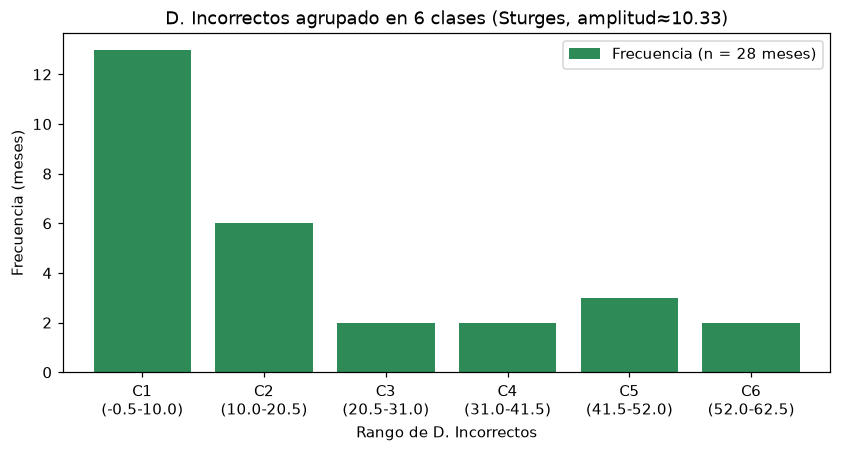

In [8]:
col = 'D_Incorrectos'; nombre = 'D. Incorrectos'
n = leads[col].count()
Max = leads[col].max(); Min = leads[col].min()
R = Max - Min
ni = int(round(1 + 3.32*np.log10(n)))
i = R/ni
print(f"[{nombre}] n={n}, Max={Max}, Min={Min}, R={R}, ni={ni}, i={round(i,2)}")

intervalos = np.linspace(Min-0.5, Max+0.5, ni+1)
categorias = [f"C{k+1}\n({round(intervalos[k],1)}-{round(intervalos[k+1],1)})" for k in range(ni)]
leads[f'{col}_clase'] = pd.cut(leads[col], bins=intervalos, labels=categorias)

Tabla_freq = leads[f'{col}_clase'].value_counts().sort_index().reset_index()
Tabla_freq.columns = ['Clase', 'count']
Filtro_index = Tabla_freq.set_index('Clase')
Filtro_index.columns = [f'Frecuencia (n = {n} meses)']

ax = Filtro_index.plot(kind='bar', width=0.8, color='seagreen', figsize=(9,4), legend=True, rot=0)
plt.title(f'{nombre} agrupado en {ni} clases (Sturges, amplitud≈{round(i,2)})')
plt.xlabel(f'Rango de {nombre}'); plt.ylabel('Frecuencia (meses)')
etiquetar_barras(ax)
plt.tight_layout(); plt.show()

[Duplicados] n=28, Max=136, Min=0, R=136, ni=6, i=22.67


NameError: name 'etiquetar_barras' is not defined

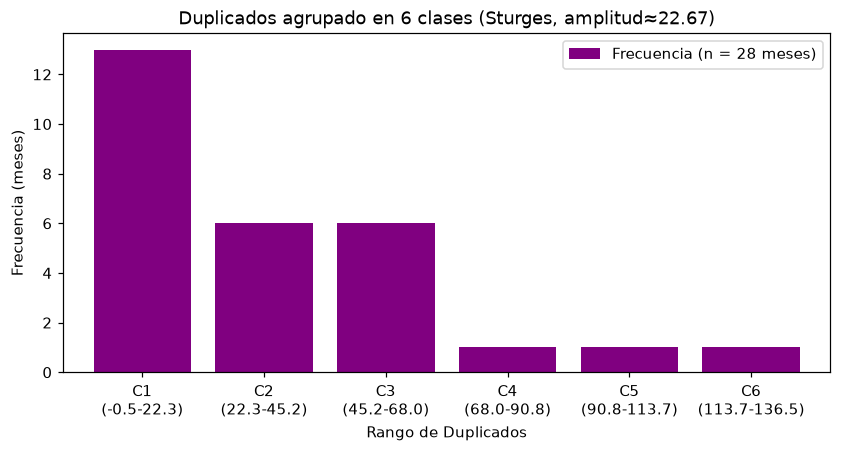

In [9]:
col = 'Duplicados'; nombre = 'Duplicados'
n = leads[col].count()
Max = leads[col].max(); Min = leads[col].min()
R = Max - Min
ni = int(round(1 + 3.32*np.log10(n)))
i = R/ni
print(f"[{nombre}] n={n}, Max={Max}, Min={Min}, R={R}, ni={ni}, i={round(i,2)}")

intervalos = np.linspace(Min-0.5, Max+0.5, ni+1)
categorias = [f"C{k+1}\n({round(intervalos[k],1)}-{round(intervalos[k+1],1)})" for k in range(ni)]
leads[f'{col}_clase'] = pd.cut(leads[col], bins=intervalos, labels=categorias)

Tabla_freq = leads[f'{col}_clase'].value_counts().sort_index().reset_index()
Tabla_freq.columns = ['Clase', 'count']
Filtro_index = Tabla_freq.set_index('Clase')
Filtro_index.columns = [f'Frecuencia (n = {n} meses)']

ax = Filtro_index.plot(kind='bar', width=0.8, color='purple', figsize=(9,4), legend=True, rot=0)
plt.title(f'{nombre} agrupado en {ni} clases (Sturges, amplitud≈{round(i,2)})')
plt.xlabel(f'Rango de {nombre}'); plt.ylabel('Frecuencia (meses)')
etiquetar_barras(ax)
plt.tight_layout(); plt.show()

[Efectivos] n=28, Max=1040, Min=128, R=912, ni=6, i=152.0


NameError: name 'etiquetar_barras' is not defined

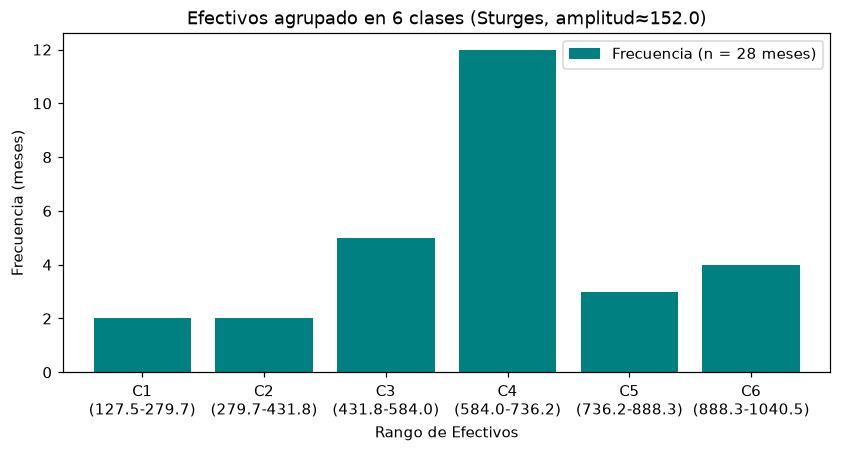

In [10]:
col = 'Efectivos'; nombre = 'Efectivos'
n = leads[col].count()
Max = leads[col].max(); Min = leads[col].min()
R = Max - Min
ni = int(round(1 + 3.32*np.log10(n)))
i = R/ni
print(f"[{nombre}] n={n}, Max={Max}, Min={Min}, R={R}, ni={ni}, i={round(i,2)}")

intervalos = np.linspace(Min-0.5, Max+0.5, ni+1)
categorias = [f"C{k+1}\n({round(intervalos[k],1)}-{round(intervalos[k+1],1)})" for k in range(ni)]
leads[f'{col}_clase'] = pd.cut(leads[col], bins=intervalos, labels=categorias)

Tabla_freq = leads[f'{col}_clase'].value_counts().sort_index().reset_index()
Tabla_freq.columns = ['Clase', 'count']
Filtro_index = Tabla_freq.set_index('Clase')
Filtro_index.columns = [f'Frecuencia (n = {n} meses)']

ax = Filtro_index.plot(kind='bar', width=0.8, color='teal', figsize=(9,4), legend=True, rot=0)
plt.title(f'{nombre} agrupado en {ni} clases (Sturges, amplitud≈{round(i,2)})')
plt.xlabel(f'Rango de {nombre}'); plt.ylabel('Frecuencia (meses)')
etiquetar_barras(ax)
plt.tight_layout(); plt.show()

[Abiertos] n=28, Max=823, Min=1, R=822, ni=6, i=137.0


NameError: name 'etiquetar_barras' is not defined

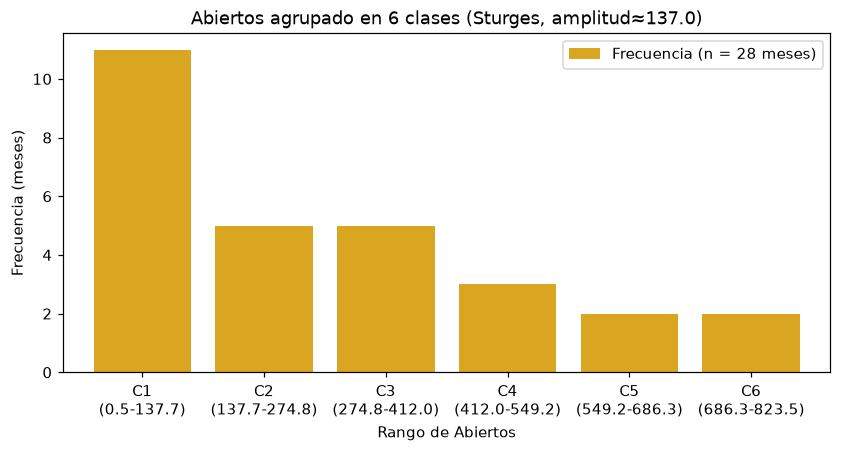

In [11]:
col = 'Abiertos'; nombre = 'Abiertos'
n = leads[col].count()
Max = leads[col].max(); Min = leads[col].min()
R = Max - Min
ni = int(round(1 + 3.32*np.log10(n)))
i = R/ni
print(f"[{nombre}] n={n}, Max={Max}, Min={Min}, R={R}, ni={ni}, i={round(i,2)}")

intervalos = np.linspace(Min-0.5, Max+0.5, ni+1)
categorias = [f"C{k+1}\n({round(intervalos[k],1)}-{round(intervalos[k+1],1)})" for k in range(ni)]
leads[f'{col}_clase'] = pd.cut(leads[col], bins=intervalos, labels=categorias)

Tabla_freq = leads[f'{col}_clase'].value_counts().sort_index().reset_index()
Tabla_freq.columns = ['Clase', 'count']
Filtro_index = Tabla_freq.set_index('Clase')
Filtro_index.columns = [f'Frecuencia (n = {n} meses)']

ax = Filtro_index.plot(kind='bar', width=0.8, color='goldenrod', figsize=(9,4), legend=True, rot=0)
plt.title(f'{nombre} agrupado en {ni} clases (Sturges, amplitud≈{round(i,2)})')
plt.xlabel(f'Rango de {nombre}'); plt.ylabel('Frecuencia (meses)')
etiquetar_barras(ax)
plt.tight_layout(); plt.show()

[Ventas] n=28, Max=41, Min=6, R=35, ni=6, i=5.83


NameError: name 'etiquetar_barras' is not defined

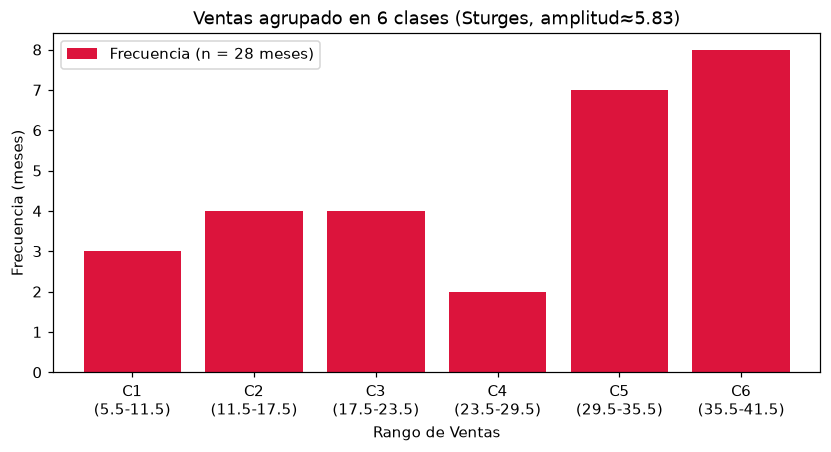

In [12]:
col = 'Ventas'; nombre = 'Ventas'
n = leads[col].count()
Max = leads[col].max(); Min = leads[col].min()
R = Max - Min
ni = int(round(1 + 3.32*np.log10(n)))
i = R/ni
print(f"[{nombre}] n={n}, Max={Max}, Min={Min}, R={R}, ni={ni}, i={round(i,2)}")

intervalos = np.linspace(Min-0.5, Max+0.5, ni+1)
categorias = [f"C{k+1}\n({round(intervalos[k],1)}-{round(intervalos[k+1],1)})" for k in range(ni)]
leads[f'{col}_clase'] = pd.cut(leads[col], bins=intervalos, labels=categorias)

Tabla_freq = leads[f'{col}_clase'].value_counts().sort_index().reset_index()
Tabla_freq.columns = ['Clase', 'count']
Filtro_index = Tabla_freq.set_index('Clase')
Filtro_index.columns = [f'Frecuencia (n = {n} meses)']

ax = Filtro_index.plot(kind='bar', width=0.8, color='crimson', figsize=(9,4), legend=True, rot=0)
plt.title(f'{nombre} agrupado en {ni} clases (Sturges, amplitud≈{round(i,2)})')
plt.xlabel(f'Rango de {nombre}'); plt.ylabel('Frecuencia (meses)')
etiquetar_barras(ax)
plt.tight_layout(); plt.show()

[Conversión] n=28, Max=5.9, Min=1.0, R=4.9, ni=6, i=0.82


NameError: name 'etiquetar_barras' is not defined

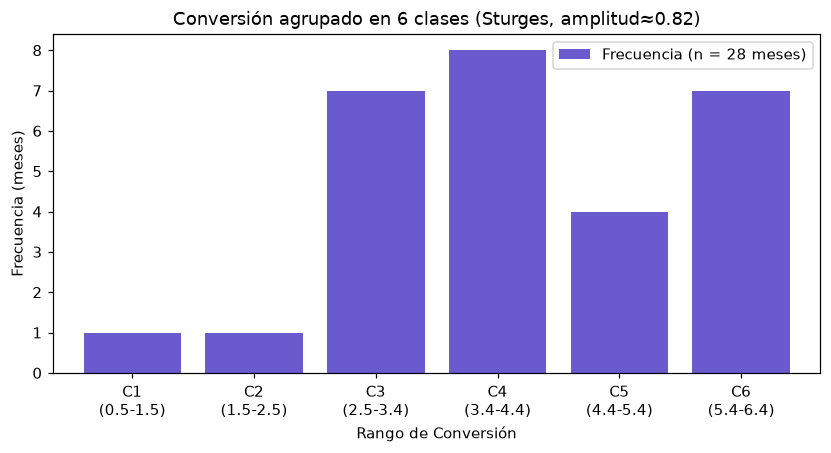

In [13]:
col = 'Conversion'; nombre = 'Conversión'
n = leads[col].count()
Max = leads[col].max(); Min = leads[col].min()
R = Max - Min
ni = int(round(1 + 3.32*np.log10(n)))
i = R/ni
print(f"[{nombre}] n={n}, Max={Max}, Min={Min}, R={R}, ni={ni}, i={round(i,2)}")

intervalos = np.linspace(Min-0.5, Max+0.5, ni+1)
categorias = [f"C{k+1}\n({round(intervalos[k],1)}-{round(intervalos[k+1],1)})" for k in range(ni)]
leads[f'{col}_clase'] = pd.cut(leads[col], bins=intervalos, labels=categorias)

Tabla_freq = leads[f'{col}_clase'].value_counts().sort_index().reset_index()
Tabla_freq.columns = ['Clase', 'count']
Filtro_index = Tabla_freq.set_index('Clase')
Filtro_index.columns = [f'Frecuencia (n = {n} meses)']

ax = Filtro_index.plot(kind='bar', width=0.8, color='slateblue', figsize=(9,4), legend=True, rot=0)
plt.title(f'{nombre} agrupado en {ni} clases (Sturges, amplitud≈{round(i,2)})')
plt.xlabel(f'Rango de {nombre}'); plt.ylabel('Frecuencia (meses)')
etiquetar_barras(ax)
plt.tight_layout(); plt.show()

In [1]:
col = 'Efectividad'; nombre = 'Efectividad de Leads'
n = leads[col].count()
ni = int(round(1 + 3.32*np.log10(n)))
i = (leads[col].max() - leads[col].min()) / ni

intervalos = np.linspace(leads[col].min()-0.5, leads[col].max()+0.5, ni+1)
categorias = [f"C{k+1}\n({round(intervalos[k],1)}-{round(intervalos[k+1],1)})" for k in range(ni)]
leads[f'{col}_clase'] = pd.cut(leads[col], bins=intervalos, labels=categorias)

# Tabla de frecuencias directa
freq = leads[f'{col}_clase'].value_counts().sort_index()

# Gráfico
ax = freq.plot(kind='bar', color='darkgreen', figsize=(9,4), rot=0)
plt.title(f'{nombre} agrupado en {ni} clases (Sturges, amplitud≈{round(i,2)})')
plt.xlabel(f'Rango de {nombre}'); plt.ylabel('Frecuencia (meses)')
plt.tight_layout(); plt.show()


NameError: name 'leads' is not defined

In [15]:
def tabla_referencia(leads, col, nombre):
    n = leads[col].count()
    Max = leads[col].max(); Min = leads[col].min()
    R = Max - Min
    ni = int(round(1 + 3.32*np.log10(n)))
    intervalos = np.linspace(Min-0.5, Max+0.5, ni+1)
    categorias = [f"C{k+1} ({round(intervalos[k],1)}-{round(intervalos[k+1],1)})" for k in range(ni)]
    leads[f'{col}_clase'] = pd.cut(leads[col], bins=intervalos, labels=categorias)
    tabla = leads[['Periodo', col, f'{col}_clase']].sort_values(col)
    print(f"--- {nombre} ---")
    display(tabla)
    return leads

for col, nombre in [('Total','Total'), ('No_Contesta','No Contesta'), ('Efectivos','Efectivos'),
                     ('Ventas','Ventas'), ('Conversion','Conversión'), ('Efectividad','Efectividad de Leads')]:
    leads = tabla_referencia(leads, col, nombre)

--- Total ---


,Periodo,Total,Total_clase
1,Mar-24,178,C1 (177.5-476.8)
2,Abr-24,416,C1 (177.5-476.8)
3,May-24,422,C1 (177.5-476.8)
0,Feb-24,543,C2 (476.8-776.2)
12,Feb-25,561,C2 (476.8-776.2)
15,May-25,815,C3 (776.2-1075.5)
13,Mar-25,925,C3 (776.2-1075.5)
5,Jul-24,954,C3 (776.2-1075.5)
4,Jun-24,967,C3 (776.2-1075.5)
11,Ene-25,1042,C3 (776.2-1075.5)


--- No Contesta ---


,Periodo,No_Contesta,No_Contesta_clase
1,Mar-24,13,C1 (12.5-111.5)
0,Feb-24,33,C1 (12.5-111.5)
12,Feb-25,39,C1 (12.5-111.5)
2,Abr-24,46,C1 (12.5-111.5)
15,May-25,75,C1 (12.5-111.5)
13,Mar-25,98,C1 (12.5-111.5)
3,May-24,100,C1 (12.5-111.5)
11,Ene-25,104,C1 (12.5-111.5)
24,Feb-26,106,C1 (12.5-111.5)
27,May-26,116,C2 (111.5-210.5)


--- Efectivos ---


...

,Periodo,Ventas,Ventas_clase
4,Jun-24,6,C1 (5.5-11.5)
1,Mar-24,7,C1 (5.5-11.5)
2,Abr-24,8,C1 (5.5-11.5)
0,Feb-24,12,C2 (11.5-17.5)
3,May-24,13,C2 (11.5-17.5)
6,Ago-24,17,C2 (11.5-17.5)
7,Sep-24,17,C2 (11.5-17.5)
12,Feb-25,20,C3 (17.5-23.5)
5,Jul-24,21,C3 (17.5-23.5)
9,Nov-24,22,C3 (17.5-23.5)


--- Conversión ---


,Periodo,Conversion,Conversion_clase
4,Jun-24,1.0,C1 (0.5-1.5)
9,Nov-24,2.1,C2 (1.5-2.5)
8,Oct-24,2.8,C3 (2.5-3.4)
2,Abr-24,2.8,C3 (2.5-3.4)
6,Ago-24,3.1,C3 (2.5-3.4)
0,Feb-24,3.1,C3 (2.5-3.4)
7,Sep-24,3.2,C3 (2.5-3.4)
10,Dic-24,3.3,C3 (2.5-3.4)
14,Abr-25,3.4,C3 (2.5-3.4)
11,Ene-25,3.6,C4 (3.4-4.4)


--- Efectividad de Leads ---


,Periodo,Efectividad,Efectividad_clase
6,Ago-24,39,C1 (38.5-46.0)
7,Sep-24,40,C1 (38.5-46.0)
8,Oct-24,42,C1 (38.5-46.0)
23,Ene-26,47,C2 (46.0-53.5)
18,Ago-25,48,C2 (46.0-53.5)
22,Dic-25,48,C2 (46.0-53.5)
26,Abr-26,52,C2 (46.0-53.5)
25,Mar-26,53,C2 (46.0-53.5)
20,Oct-25,58,C3 (53.5-61.0)
27,May-26,59,C3 (53.5-61.0)
